# COVID-19 Symptom Classification: Efficient 1M Row ML Workflow

This notebook builds a complete, reproducible machine learning workflow using 1,000,000 patient records from the COVID-19 dataset published on Kaggle: [COVID-19 Dataset for Year 2020](https://www.kaggle.com/datasets/mykeysid10/covid19-dataset-for-year-2020).

It keeps the five symptom features requested: cough, 
ever, sore_throat, shortness_of_breath, and head_ache, and adds a few helpful context features from the same dataset so the models have a fairer chance to learn useful patterns.

We compare seven models: Logistic Regression, Random Forest, Extra Trees, PCA + Linear SVM, XGBoost, LightGBM, and CatBoost. The notebook tries GPU acceleration where it makes sense, falls back to CPU if that fails, tunes the strongest models, and saves the best final model. The original dataset is only read from disk and is never overwritten.


## 1. Dependency Check

Before doing any modelling, this cell checks whether the active Jupyter kernel has the packages we need. It prints a ready-to-run install command if something is missing. By default it will not install anything automatically, which keeps the notebook predictable.


In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
    "xgboost": "xgboost",
    "lightgbm": "lightgbm",
    "catboost": "catboost",
}

INSTALL_MISSING = False

missing = [
    pip_name
    for import_name, pip_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]

if missing:
    print("Missing packages:", missing)
    print("Install command:")
    print(f"{sys.executable} -m pip install " + " ".join(missing))
    print("Or install the full project requirements:")
    print(f"{sys.executable} -m pip install -r requirements_ml.txt")
    if INSTALL_MISSING:
        subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
else:
    print("All required packages are available.")


All required packages are available.


## 2. Imports and Configuration

The configuration keeps memory use low by reading only the useful columns from the Kaggle CSV after it has been downloaded locally. Outputs go into ml_outputs, so the source dataset stays exactly as it is.


In [2]:
import json
import os
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from joblib import dump
from sklearn.base import clone
from sklearn.decomposition import PCA
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

DATA_PATH = Path("covid_data_2020_2021.csv")
OUTPUT_DIR = Path("ml_outputs")
MODEL_DIR = OUTPUT_DIR / "models"
OUTPUT_DIR.mkdir(exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SYMPTOM_COLUMNS = ["cough", "fever", "sore_throat", "shortness_of_breath", "head_ache"]
CONTEXT_COLUMNS = ["test_date", "age_60_and_above", "gender", "test_indication"]
TARGET_COLUMN = "corona_result"
USE_COLUMNS = SYMPTOM_COLUMNS + CONTEXT_COLUMNS + [TARGET_COLUMN]

N_ROWS = 1_000_000
RANDOM_STATE = 42
TEST_SIZE = 0.20
TOP_N_MODELS_TO_TUNE = 3
MAX_RANDOM_SEARCH_ITERATIONS = 10
N_JOBS = max(os.cpu_count() - 1, 1)

print(f"CPU threads available: {os.cpu_count()}")
print(f"Using up to {N_JOBS} worker threads for CPU models/searches.")
print(f"Dataset path: {DATA_PATH.resolve()}")


CPU threads available: 22
Using up to 21 worker threads for CPU models/searches.
Dataset path: C:\Users\edyki\OneDrive\Documents\CodexFolder\covid_data_2020_2021.csv


## 3. Load 1 Million Rows Efficiently

This cell reads 1 million records, but only the columns we plan to use. That keeps memory use friendly on a large file. The target is normalized to binary values: `Positive = 1`, `Negative = 0`. Any row with an unexpected target value is removed so the models learn a clean two-class problem.


In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH.resolve()}")

dtype_map = {col: "int8" for col in SYMPTOM_COLUMNS}
dtype_map[TARGET_COLUMN] = "category"

df = pd.read_csv(
    DATA_PATH,
    usecols=USE_COLUMNS,
    dtype=dtype_map,
    nrows=N_ROWS,
    low_memory=False,
)

target_map = {"Negative": 0, "Positive": 1, "negative": 0, "positive": 1, 0: 0, 1: 1}
df[TARGET_COLUMN] = df[TARGET_COLUMN].map(target_map)
df = df.dropna(subset=[TARGET_COLUMN]).copy()
df[TARGET_COLUMN] = df[TARGET_COLUMN].astype("int8")

for col in SYMPTOM_COLUMNS:
    df[col] = pd.to_numeric(df[col], errors="coerce").astype("float32")

print(df.shape)
print(df.head())
print("\nMemory usage MB:", round(df.memory_usage(deep=True).sum() / 1024**2, 2))
print("\nTarget distribution:")
print(df[TARGET_COLUMN].value_counts(normalize=True).rename("proportion"))
print(df[TARGET_COLUMN].value_counts().rename("count"))


(1000000, 10)
    test_date  cough  fever  sore_throat  shortness_of_breath  head_ache  \
0  2021-10-11    0.0    0.0          0.0                  0.0        0.0   
1  2021-10-11    0.0    0.0          0.0                  0.0        0.0   
2  2021-10-11    0.0    0.0          0.0                  0.0        0.0   
3  2021-10-11    0.0    0.0          0.0                  0.0        0.0   
4  2021-10-11    0.0    0.0          0.0                  0.0        0.0   

   corona_result age_60_and_above  gender test_indication  
0              0              Yes  female           Other  
1              0              Yes    male           Other  
2              0               No  female           Other  
3              0              Yes  female           Other  
4              0              Yes  female           Other  



Memory usage MB: 228.66

Target distribution:
corona_result
0    0.908967
1    0.091033
Name: proportion, dtype: float64
corona_result
0    908967
1     91033
Name: count, dtype: int64


## 4. First Look at the Data

Before modelling, it helps to look at the shape of the problem. These charts show how imbalanced the target is and how often each symptom appears in positive and negative cases.


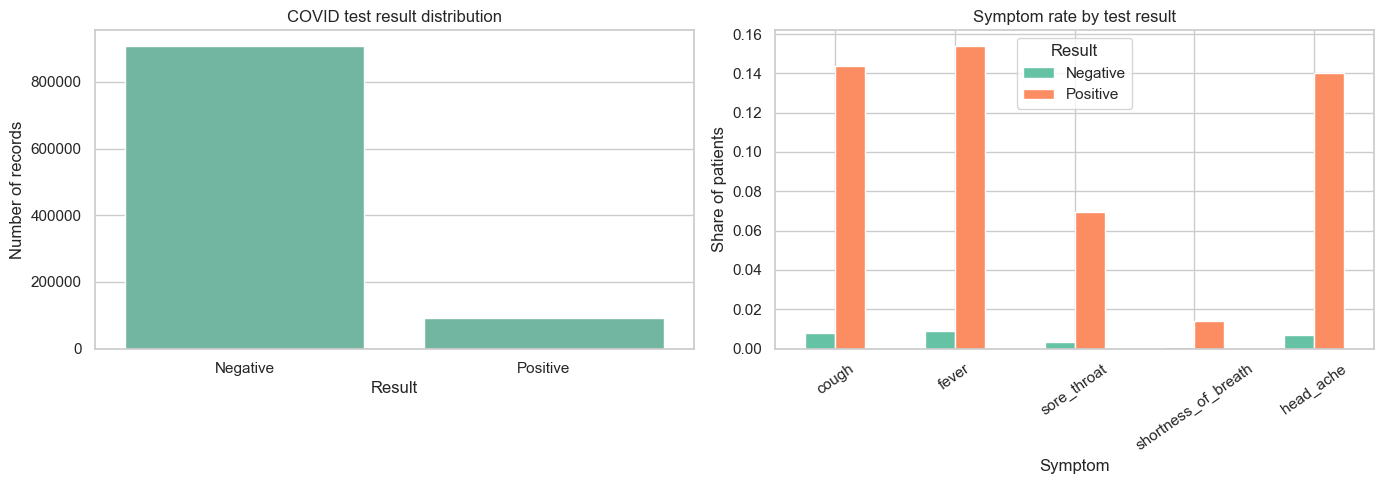

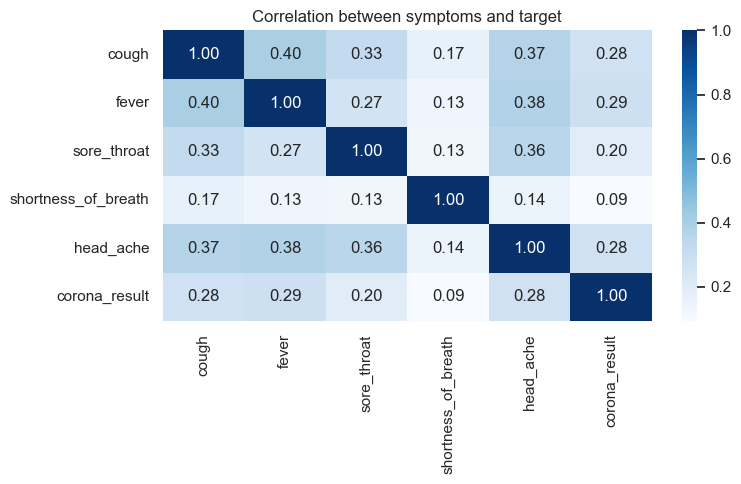

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

target_counts = df[TARGET_COLUMN].map({0: "Negative", 1: "Positive"}).value_counts()
sns.barplot(x=target_counts.index, y=target_counts.values, ax=axes[0])
axes[0].set_title("COVID test result distribution")
axes[0].set_xlabel("Result")
axes[0].set_ylabel("Number of records")

symptom_rates = (
    df.groupby(TARGET_COLUMN)[SYMPTOM_COLUMNS]
    .mean()
    .rename(index={0: "Negative", 1: "Positive"})
    .T
)
symptom_rates.plot(kind="bar", ax=axes[1])
axes[1].set_title("Symptom rate by test result")
axes[1].set_xlabel("Symptom")
axes[1].set_ylabel("Share of patients")
axes[1].tick_params(axis="x", rotation=35)
axes[1].legend(title="Result")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.heatmap(df[SYMPTOM_COLUMNS + [TARGET_COLUMN]].corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation between symptoms and target")
plt.tight_layout()
plt.show()


## 5. Clean Missing Values

Real datasets are rarely perfectly tidy. The symptom columns are supposed to be binary, so missing or odd symptom values are filled sensibly and clipped to the valid 0/1 range. The context columns are also cleaned into simple, consistent labels before we turn them into numeric model features.


In [5]:
missing_before = df[USE_COLUMNS].isna().sum()

for col in SYMPTOM_COLUMNS:
    median_value = df[col].median()
    df[col] = df[col].fillna(median_value).clip(0, 1).astype("int8")

for col in ["age_60_and_above", "gender", "test_indication"]:
    df[col] = df[col].astype("string").str.strip().fillna("Unknown")

missing_after = df[USE_COLUMNS].isna().sum()

print("Missing values before cleaning:")
print(missing_before)
print("\nMissing values after cleaning:")
print(missing_after)


Missing values before cleaning:
cough                  0
fever                  0
sore_throat            0
shortness_of_breath    0
head_ache              0
test_date              0
age_60_and_above       0
gender                 0
test_indication        0
corona_result          0
dtype: int64

Missing values after cleaning:
cough                  0
fever                  0
sore_throat            0
shortness_of_breath    0
head_ache              0
test_date              0
age_60_and_above       0
gender                 0
test_indication        0
corona_result          0
dtype: int64


## 6. Feature Engineering and Train/Test Split

This is where we give the models a little more signal to work with. The five symptoms remain the foundation, and we add small, explainable features: total symptom count, whether the patient has any symptom, whether symptoms are stacked together, older-age flag, gender flags, test indication flags, and simple date features. The split is stratified so the test set keeps the same positive/negative balance as the full million-row sample.


In [6]:
def make_features(raw_df):
    features = raw_df[SYMPTOM_COLUMNS].copy()

    features["symptom_count"] = features[SYMPTOM_COLUMNS].sum(axis=1).astype("int8")
    features["has_any_symptom"] = (features["symptom_count"] > 0).astype("int8")
    features["has_multiple_symptoms"] = (features["symptom_count"] >= 2).astype("int8")

    features["age_60_and_above_yes"] = (
        raw_df["age_60_and_above"].astype("string").str.lower().eq("yes")
    ).astype("int8")

    gender_dummies = pd.get_dummies(
        raw_df["gender"].astype("string").str.lower().fillna("unknown"),
        prefix="gender",
        dtype="int8",
    )
    indication_dummies = pd.get_dummies(
        raw_df["test_indication"].astype("string").str.lower().fillna("unknown"),
        prefix="test_indication",
        dtype="int8",
    )

    test_dates = pd.to_datetime(raw_df["test_date"], errors="coerce")
    date_features = pd.DataFrame(index=raw_df.index)
    date_features["test_month"] = test_dates.dt.month.fillna(0).astype("int8")
    date_features["test_dayofweek"] = test_dates.dt.dayofweek.fillna(0).astype("int8")

    features = pd.concat([features, gender_dummies, indication_dummies, date_features], axis=1)
    return features.astype("float32")


X = make_features(df)
MODEL_FEATURE_COLUMNS = X.columns.tolist()
y = df[TARGET_COLUMN]

print(f"Engineered {len(MODEL_FEATURE_COLUMNS)} model features:")
print(MODEL_FEATURE_COLUMNS)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

positive_count = int((y_train == 1).sum())
negative_count = int((y_train == 0).sum())
scale_pos_weight = negative_count / max(positive_count, 1)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Training target distribution:")
print(y_train.value_counts(normalize=True))
print(f"scale_pos_weight for boosted trees: {scale_pos_weight:.3f}")


Engineered 16 model features:
['cough', 'fever', 'sore_throat', 'shortness_of_breath', 'head_ache', 'symptom_count', 'has_any_symptom', 'has_multiple_symptoms', 'age_60_and_above_yes', 'gender_female', 'gender_male', 'test_indication_abroad', 'test_indication_contact with confirmed', 'test_indication_other', 'test_month', 'test_dayofweek']


Train: (800000, 16) Test: (200000, 16)
Training target distribution:
corona_result
0    0.908968
1    0.091033
Name: proportion, dtype: float64
scale_pos_weight for boosted trees: 9.985


## 7. Engineered Feature Visuals

These charts give a quick sanity check on the new features. They help us see whether the added context is carrying useful signal, without making the notebook too heavy.


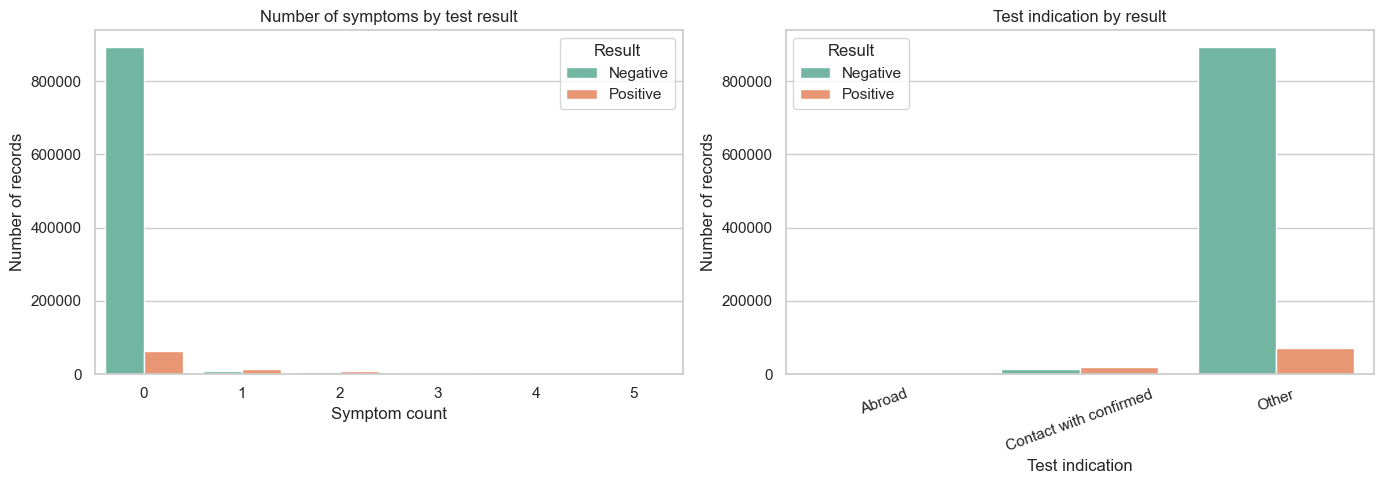

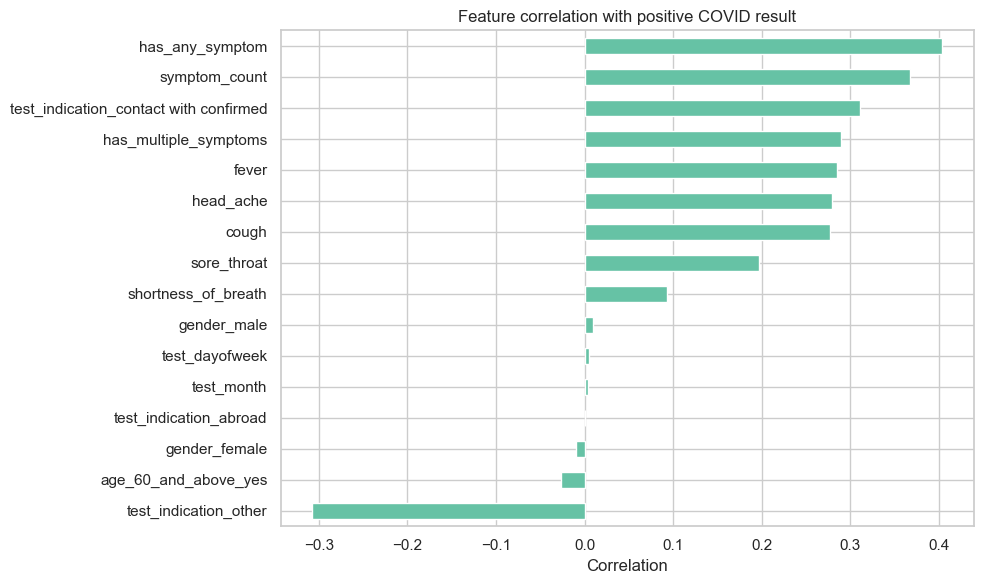

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x=df[SYMPTOM_COLUMNS].sum(axis=1), hue=df[TARGET_COLUMN].map({0: "Negative", 1: "Positive"}), ax=axes[0])
axes[0].set_title("Number of symptoms by test result")
axes[0].set_xlabel("Symptom count")
axes[0].set_ylabel("Number of records")
axes[0].legend(title="Result")

indication_plot = (
    df.assign(result=df[TARGET_COLUMN].map({0: "Negative", 1: "Positive"}))
    .groupby(["test_indication", "result"])
    .size()
    .reset_index(name="records")
)
sns.barplot(data=indication_plot, x="test_indication", y="records", hue="result", ax=axes[1])
axes[1].set_title("Test indication by result")
axes[1].set_xlabel("Test indication")
axes[1].set_ylabel("Number of records")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend(title="Result")

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
feature_target_corr = X.assign(target=y).corr(numeric_only=True)["target"].drop("target").sort_values()
feature_target_corr.plot(kind="barh")
plt.title("Feature correlation with positive COVID result")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()


## 8. Model Setup with GPU Fallback

The helper functions below build seven models. XGBoost, LightGBM, and CatBoost first try GPU settings because your machine has a graphics card. If the Python packages are not GPU-enabled, or if the GPU setup is not available in this Jupyter environment, the notebook falls back to CPU and keeps going.


In [8]:
def optional_import(module_name, object_name=None):
    try:
        module = __import__(module_name, fromlist=[object_name] if object_name else [])
        return getattr(module, object_name) if object_name else module
    except Exception as exc:
        print(f"Skipping {module_name}: {exc}")
        return None


XGBClassifier = optional_import("xgboost", "XGBClassifier")
LGBMClassifier = optional_import("lightgbm", "LGBMClassifier")
CatBoostClassifier = optional_import("catboost", "CatBoostClassifier")


def build_model_specs():
    specs = {}

    specs["Logistic Regression"] = {
        "gpu": None,
        "cpu": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                (
                    "model",
                    LogisticRegression(
                        class_weight="balanced",
                        max_iter=500,
                        solver="saga",
                        n_jobs=N_JOBS,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
    }

    specs["Random Forest"] = {
        "gpu": None,
        "cpu": RandomForestClassifier(
            n_estimators=300,
            max_depth=18,
            min_samples_leaf=10,
            max_features="sqrt",
            class_weight="balanced_subsample",
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
        ),
    }

    specs["Extra Trees"] = {
        "gpu": None,
        "cpu": ExtraTreesClassifier(
            n_estimators=400,
            max_depth=18,
            min_samples_leaf=10,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=N_JOBS,
            random_state=RANDOM_STATE,
        ),
    }

    specs["PCA + Linear SVM"] = {
        "gpu": None,
        "cpu": Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
                (
                    "model",
                    LinearSVC(
                        C=1.0,
                        class_weight="balanced",
                        max_iter=5000,
                        dual=False,
                        random_state=RANDOM_STATE,
                    ),
                ),
            ]
        ),
    }

    if XGBClassifier is not None:
        common = dict(
            objective="binary:logistic",
            eval_metric="auc",
            n_estimators=400,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.85,
            colsample_bytree=1.0,
            scale_pos_weight=scale_pos_weight,
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
        )
        specs["XGBoost"] = {
            "gpu": XGBClassifier(**common, tree_method="hist", device="cuda"),
            "cpu": XGBClassifier(**common, tree_method="hist", device="cpu"),
        }

    if LGBMClassifier is not None:
        common = dict(
            objective="binary",
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=31,
            subsample=0.85,
            colsample_bytree=1.0,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=N_JOBS,
            verbose=-1,
        )
        specs["LightGBM"] = {
            "gpu": LGBMClassifier(**common, device_type="gpu"),
            "cpu": LGBMClassifier(**common, device_type="cpu"),
        }

    if CatBoostClassifier is not None:
        common = dict(
            loss_function="Logloss",
            eval_metric="AUC",
            iterations=500,
            depth=6,
            learning_rate=0.05,
            auto_class_weights="Balanced",
            random_seed=RANDOM_STATE,
            verbose=False,
            allow_writing_files=False,
        )
        specs["CatBoost"] = {
            "gpu": CatBoostClassifier(**common, task_type="GPU"),
            "cpu": CatBoostClassifier(**common, task_type="CPU", thread_count=N_JOBS),
        }

    return specs


model_specs = build_model_specs()
print("Models available for training:", list(model_specs))


Models available for training: ['Logistic Regression', 'Random Forest', 'Extra Trees', 'PCA + Linear SVM', 'XGBoost', 'LightGBM', 'CatBoost']


## 9. Evaluation Helpers

These functions score every model in the same way, so the comparison is fair. Accuracy is included, but because COVID-positive cases are much rarer than negative cases in this sample, ROC-AUC, recall, precision, and F1-score are especially important.


In [9]:
def predict_scores(model, X_values):
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_values)
        return scores[:, 1] if scores.ndim == 2 else scores
    if hasattr(model, "decision_function"):
        raw_scores = model.decision_function(X_values)
        return 1 / (1 + np.exp(-raw_scores))
    return model.predict(X_values)


def evaluate_model(model, X_values, y_true):
    y_score = predict_scores(model, X_values)
    y_pred = (y_score >= 0.5).astype(int)

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }


def fit_with_gpu_fallback(name, spec, X_fit, y_fit):
    candidates = []
    if spec.get("gpu") is not None:
        candidates.append(("GPU", spec["gpu"]))
    candidates.append(("CPU", spec["cpu"]))

    errors = []
    for device, estimator in candidates:
        try:
            start = time.time()
            fitted = clone(estimator).fit(X_fit, y_fit)
            elapsed = time.time() - start
            print(f"{name} trained on {device} in {elapsed:.1f}s")
            return fitted, device, elapsed
        except Exception as exc:
            errors.append(f"{device}: {exc}")
            print(f"{name} {device} training failed. Falling back if possible.")

    raise RuntimeError(f"{name} failed on all devices: {errors}")


## 10. Train Baseline Models

This cell gives every requested model a solid first attempt using efficient starter settings. We do this before tuning so we spend the expensive search time only on models that are actually performing well.


In [10]:
fitted_models = {}
baseline_rows = []

for name, spec in model_specs.items():
    print("\n" + "=" * 80)
    print(f"Training {name}")
    try:
        model, device, elapsed = fit_with_gpu_fallback(name, spec, X_train, y_train)
        metrics = evaluate_model(model, X_test, y_test)
        fitted_models[name] = model
        baseline_rows.append(
            {
                "model": name,
                "device": device,
                "train_seconds": elapsed,
                **{k: v for k, v in metrics.items() if k != "confusion_matrix"},
                "confusion_matrix": metrics["confusion_matrix"],
            }
        )
        print(metrics)
    except Exception as exc:
        baseline_rows.append({"model": name, "error": str(exc)})
        print(f"{name} failed: {exc}")

baseline_results = pd.DataFrame(baseline_rows)
display(baseline_results.sort_values("roc_auc", ascending=False, na_position="last"))
baseline_results.to_csv(OUTPUT_DIR / "baseline_model_results.csv", index=False)



Training Logistic Regression


Logistic Regression trained on CPU in 9.7s
{'accuracy': 0.922925, 'precision': 0.6260610438865812, 'recall': 0.3807876091613116, 'f1': 0.4735494006352242, 'roc_auc': 0.7110106802574051, 'confusion_matrix': [[177652, 4141], [11274, 6933]]}

Training Random Forest


Random Forest trained on CPU in 26.6s


{'accuracy': 0.923255, 'precision': 0.6299799890849554, 'recall': 0.3804031416488164, 'f1': 0.4743673161878018, 'roc_auc': 0.7427435285440903, 'confusion_matrix': [[177725, 4068], [11281, 6926]]}

Training Extra Trees


Extra Trees trained on CPU in 18.9s


...

LightGBM trained on GPU in 13.1s


{'accuracy': 0.923235, 'precision': 0.6297508637934169, 'recall': 0.3804031416488164, 'f1': 0.4743023454887862, 'roc_auc': 0.7430839005331968, 'confusion_matrix': [[177721, 4072], [11281, 6926]]}

Training CatBoost


Default metric period is 5 because AUC is/are not implemented for GPU


CatBoost trained on GPU in 4.1s
{'accuracy': 0.923225, 'precision': 0.6296363636363637, 'recall': 0.3804031416488164, 'f1': 0.47426986681275035, 'roc_auc': 0.7427652865693857, 'confusion_matrix': [[177719, 4074], [11281, 6926]]}


,model,device,train_seconds,accuracy,precision,recall,f1,roc_auc,confusion_matrix
4,XGBoost,GPU,1.377885,0.923230,0.629646,0.380513,0.474358,0.743262,"[[177718, 4075], [11279, 6928]]"
5,LightGBM,GPU,13.140724,0.923235,0.629751,0.380403,0.474302,0.743084,"[[177721, 4072], [11281, 6926]]"
6,CatBoost,GPU,4.146556,0.923225,0.629636,0.380403,0.474270,0.742765,"[[177719, 4074], [11281, 6926]]"
1,Random Forest,CPU,26.551879,0.923255,0.629980,0.380403,0.474367,0.742744,"[[177725, 4068], [11281, 6926]]"
2,Extra Trees,CPU,18.945899,0.923220,0.629579,0.380403,0.474254,0.742538,"[[177718, 4075], [11281, 6926]]"
0,Logistic Regression,CPU,9.748868,0.922925,0.626061,0.380788,0.473549,0.711011,"[[177652, 4141], [11274, 6933]]"
3,PCA + Linear SVM,CPU,0.879107,0.922780,0.625374,0.378481,0.471566,0.710950,"[[177665, 4128], [11316, 6891]]"


## 11. Compare Baseline Models Visually

Tables are useful, but charts make the tradeoffs easier to see. These plots compare the main metrics and show each model's confusion matrix.


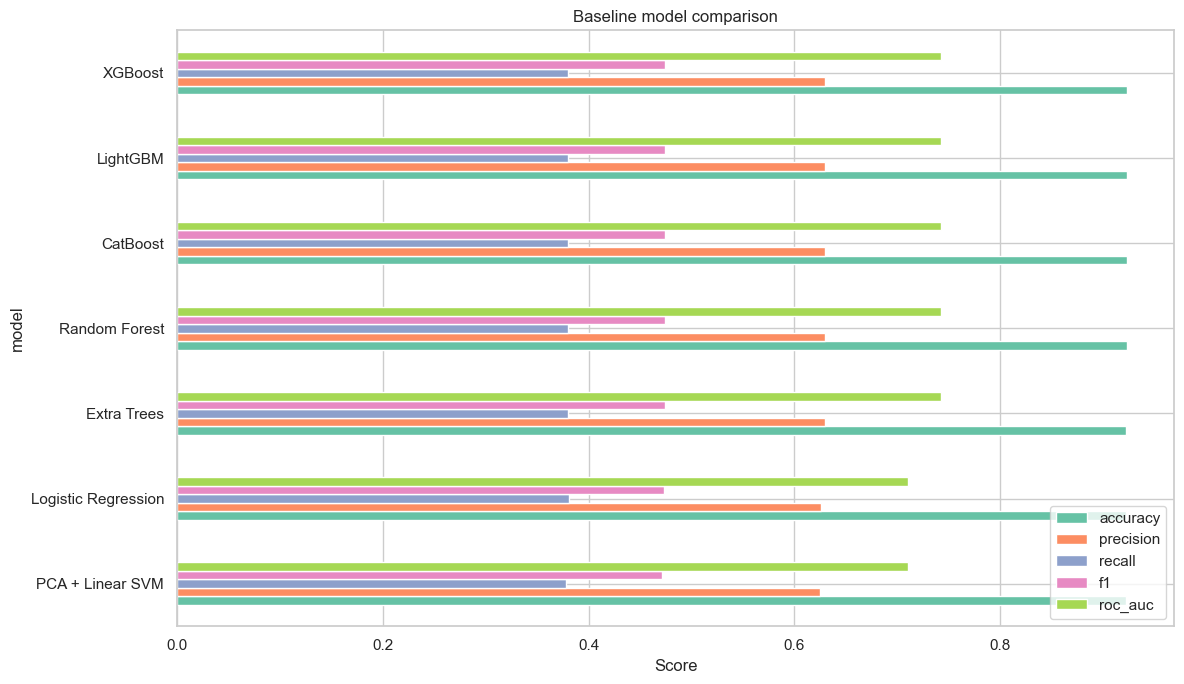

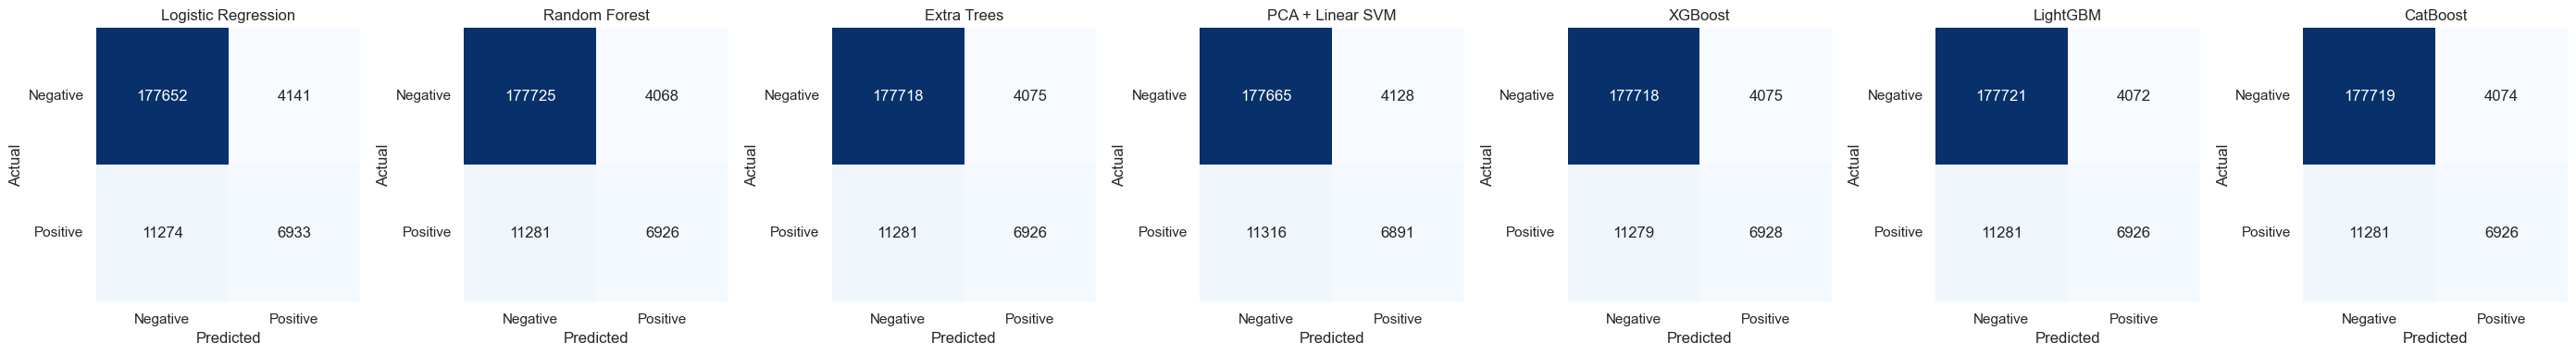

In [11]:
metric_columns = ["accuracy", "precision", "recall", "f1", "roc_auc"]
plot_results = baseline_results.dropna(subset=["roc_auc"]).set_index("model")[metric_columns]

ax = plot_results.sort_values("roc_auc").plot(kind="barh", figsize=(12, 7))
ax.set_title("Baseline model comparison")
ax.set_xlabel("Score")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

valid_rows = baseline_results.dropna(subset=["roc_auc"]).reset_index(drop=True)
n_models = len(valid_rows)
fig, axes = plt.subplots(1, n_models, figsize=(4 * n_models, 4))
if n_models == 1:
    axes = [axes]

for ax, (_, row) in zip(axes, valid_rows.iterrows()):
    sns.heatmap(row["confusion_matrix"], annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(row["model"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(["Negative", "Positive"])
    ax.set_yticklabels(["Negative", "Positive"], rotation=0)

plt.tight_layout()
plt.show()


## 12. Select the Top Models for Tuning

ROC-AUC is used as the main ranking metric because the dataset is imbalanced. F1-score is used as a second check because it balances precision and recall. In plain terms: we want a model that separates positives from negatives well, but also behaves sensibly at the decision threshold.


In [12]:
valid_baselines = baseline_results.dropna(subset=["roc_auc"]).copy()
if valid_baselines.empty:
    raise RuntimeError("No models trained successfully. Check package installation and earlier error messages.")

top_models = (
    valid_baselines
    .sort_values(["roc_auc", "f1"], ascending=False)
    .head(TOP_N_MODELS_TO_TUNE)["model"]
    .tolist()
)

print("Top models selected for tuning:", top_models)
display(valid_baselines.sort_values(["roc_auc", "f1"], ascending=False))


Top models selected for tuning: ['XGBoost', 'LightGBM', 'CatBoost']


,model,device,train_seconds,accuracy,precision,recall,f1,roc_auc,confusion_matrix
4,XGBoost,GPU,1.377885,0.923230,0.629646,0.380513,0.474358,0.743262,"[[177718, 4075], [11279, 6928]]"
5,LightGBM,GPU,13.140724,0.923235,0.629751,0.380403,0.474302,0.743084,"[[177721, 4072], [11281, 6926]]"
6,CatBoost,GPU,4.146556,0.923225,0.629636,0.380403,0.474270,0.742765,"[[177719, 4074], [11281, 6926]]"
1,Random Forest,CPU,26.551879,0.923255,0.629980,0.380403,0.474367,0.742744,"[[177725, 4068], [11281, 6926]]"
2,Extra Trees,CPU,18.945899,0.923220,0.629579,0.380403,0.474254,0.742538,"[[177718, 4075], [11281, 6926]]"
0,Logistic Regression,CPU,9.748868,0.922925,0.626061,0.380788,0.473549,0.711011,"[[177652, 4141], [11274, 6933]]"
3,PCA + Linear SVM,CPU,0.879107,0.922780,0.625374,0.378481,0.471566,0.710950,"[[177665, 4128], [11316, 6891]]"


## 13. Tune the Top Models

Tuning is intentionally focused. A huge grid search can take a very long time on 1 million rows, so this notebook tunes the top three models with randomized search over sensible ranges. It is usually a better tradeoff: stronger results without turning the machine into a space heater for half a day.


In [13]:
def tuning_space_for(name):
    if name == "Logistic Regression":
        return {
            "model__C": np.logspace(-2, 2, 9),
            "model__penalty": ["l2"],
        }
    if name == "Random Forest":
        return {
            "n_estimators": [250, 400, 600],
            "max_depth": [8, 12, 18, None],
            "min_samples_leaf": [5, 10, 25, 50],
            "max_features": ["sqrt", None],
        }
    if name == "Extra Trees":
        return {
            "n_estimators": [300, 500, 700],
            "max_depth": [8, 12, 18, None],
            "min_samples_leaf": [5, 10, 25, 50],
            "max_features": ["sqrt", None],
        }
    if name == "PCA + Linear SVM":
        return {
            "pca__n_components": [0.80, 0.90, 0.95, None],
            "model__C": np.logspace(-2, 2, 7),
        }
    if name == "XGBoost":
        return {
            "n_estimators": [300, 500, 700],
            "max_depth": [2, 3, 4, 5],
            "learning_rate": [0.03, 0.05, 0.08, 0.12],
            "subsample": [0.75, 0.85, 1.0],
            "colsample_bytree": [0.8, 1.0],
            "min_child_weight": [1, 5, 10],
        }
    if name == "LightGBM":
        return {
            "n_estimators": [300, 500, 700],
            "num_leaves": [15, 31, 63],
            "learning_rate": [0.03, 0.05, 0.08, 0.12],
            "subsample": [0.75, 0.85, 1.0],
            "colsample_bytree": [0.8, 1.0],
            "min_child_samples": [20, 50, 100],
        }
    if name == "CatBoost":
        return {
            "iterations": [300, 500, 700],
            "depth": [4, 6, 8],
            "learning_rate": [0.03, 0.05, 0.08, 0.12],
            "l2_leaf_reg": [1, 3, 5, 7],
        }
    return {}


cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
tuned_models = {}
tuned_rows = []

for name in top_models:
    print("\n" + "=" * 80)
    print(f"Tuning {name}")
    base_model = fitted_models[name]
    param_space = tuning_space_for(name)

    search = RandomizedSearchCV(
        estimator=base_model,
        param_distributions=param_space,
        n_iter=min(MAX_RANDOM_SEARCH_ITERATIONS, np.prod([len(v) for v in param_space.values()]) if param_space else 1),
        scoring="roc_auc",
        cv=cv,
        random_state=RANDOM_STATE,
        n_jobs=1 if name in {"XGBoost", "LightGBM", "CatBoost", "PCA + Linear SVM"} else N_JOBS,
        verbose=1,
        refit=True,
    )

    start = time.time()
    try:
        search.fit(X_train, y_train)
    except Exception as exc:
        print(f"Tuning failed for {name}: {exc}")
        continue

    elapsed = time.time() - start
    best_model = search.best_estimator_
    tuned_models[name] = best_model
    metrics = evaluate_model(best_model, X_test, y_test)

    tuned_rows.append(
        {
            "model": name,
            "tuned_train_seconds": elapsed,
            "best_cv_roc_auc": search.best_score_,
            "best_params": search.best_params_,
            **{k: v for k, v in metrics.items() if k != "confusion_matrix"},
            "confusion_matrix": metrics["confusion_matrix"],
        }
    )
    print("Best params:", search.best_params_)
    print(metrics)

tuned_results = pd.DataFrame(tuned_rows)
if not tuned_results.empty:
    display(tuned_results.sort_values(["roc_auc", "f1"], ascending=False))
    tuned_results.to_csv(OUTPUT_DIR / "tuned_model_results.csv", index=False)
else:
    print("No tuned models completed; the best baseline model will be saved instead.")



Tuning XGBoost
Fitting 3 folds for each of 10 candidates, totalling 30 fits


Best params: {'subsample': 0.75, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
{'accuracy': 0.92325, 'precision': 0.6298754432221111, 'recall': 0.3805129895095293, 'f1': 0.47442306375402316, 'roc_auc': 0.74302160735844, 'confusion_matrix': [[177722, 4071], [11279, 6928]]}

Tuning LightGBM
Fitting 3 folds for each of 10 candidates, totalling 30 fits


Best params: {'subsample': 0.85, 'num_leaves': 31, 'n_estimators': 300, 'min_child_samples': 100, 'learning_rate': 0.08, 'colsample_bytree': 0.8}
{'accuracy': 0.923175, 'precision': 0.628900580551524, 'recall': 0.3807876091613116, 'f1': 0.474359412952003, 'roc_auc': 0.743357625597411, 'confusion_matrix': [[177702, 4091], [11274, 6933]]}

Tuning CatBoost
Fitting 3 folds for each of 10 candidates, totalling 30 fits


Default metric period is 5 because AUC is/are not implemented for GPU


Default metric period is 5 because AUC is/are not implemented for GPU


...

Default metric period is 5 because AUC is/are not implemented for GPU


Default metric period is 5 because AUC is/are not implemented for GPU


Default metric period is 5 because AUC is/are not implemented for GPU


Best params: {'learning_rate': 0.08, 'l2_leaf_reg': 1, 'iterations': 500, 'depth': 4}
{'accuracy': 0.923225, 'precision': 0.6296363636363637, 'recall': 0.3804031416488164, 'f1': 0.47426986681275035, 'roc_auc': 0.7431071447037971, 'confusion_matrix': [[177719, 4074], [11281, 6926]]}


,model,tuned_train_seconds,best_cv_roc_auc,best_params,accuracy,precision,recall,f1,roc_auc,confusion_matrix
1,LightGBM,381.881636,0.743432,"{'subsample': 0.85, 'num_leaves': 31, 'n_estim...",0.923175,0.628901,0.380788,0.474359,0.743358,"[[177702, 4091], [11274, 6933]]"
2,CatBoost,100.365027,0.743425,"{'learning_rate': 0.08, 'l2_leaf_reg': 1, 'ite...",0.923225,0.629636,0.380403,0.474270,0.743107,"[[177719, 4074], [11281, 6926]]"
0,XGBoost,43.564812,0.743462,"{'subsample': 0.75, 'n_estimators': 300, 'min_...",0.923250,0.629875,0.380513,0.474423,0.743022,"[[177722, 4071], [11279, 6928]]"


## 14. Compare Tuned Models

After tuning, we compare the stronger final candidates and draw ROC curves. The ROC curve shows how well a model separates positive from negative cases across possible thresholds.


,model,tuned_train_seconds,best_cv_roc_auc,best_params,accuracy,precision,recall,f1,roc_auc,confusion_matrix
1,LightGBM,381.881636,0.743432,"{'subsample': 0.85, 'num_leaves': 31, 'n_estim...",0.923175,0.628901,0.380788,0.474359,0.743358,"[[177702, 4091], [11274, 6933]]"
2,CatBoost,100.365027,0.743425,"{'learning_rate': 0.08, 'l2_leaf_reg': 1, 'ite...",0.923225,0.629636,0.380403,0.474270,0.743107,"[[177719, 4074], [11281, 6926]]"
0,XGBoost,43.564812,0.743462,"{'subsample': 0.75, 'n_estimators': 300, 'min_...",0.923250,0.629875,0.380513,0.474423,0.743022,"[[177722, 4071], [11279, 6928]]"


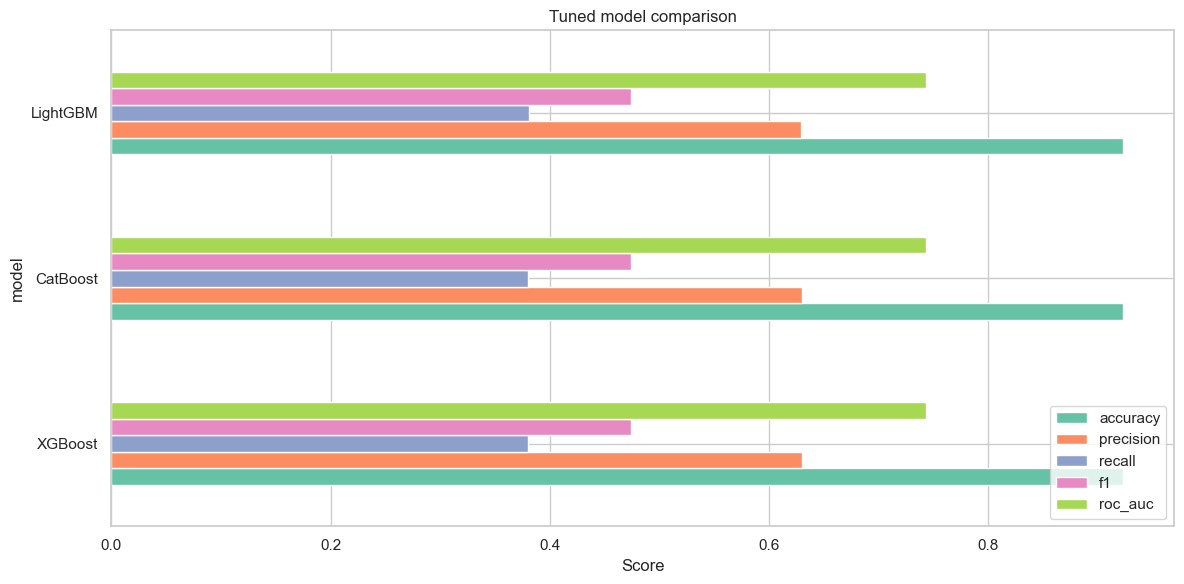

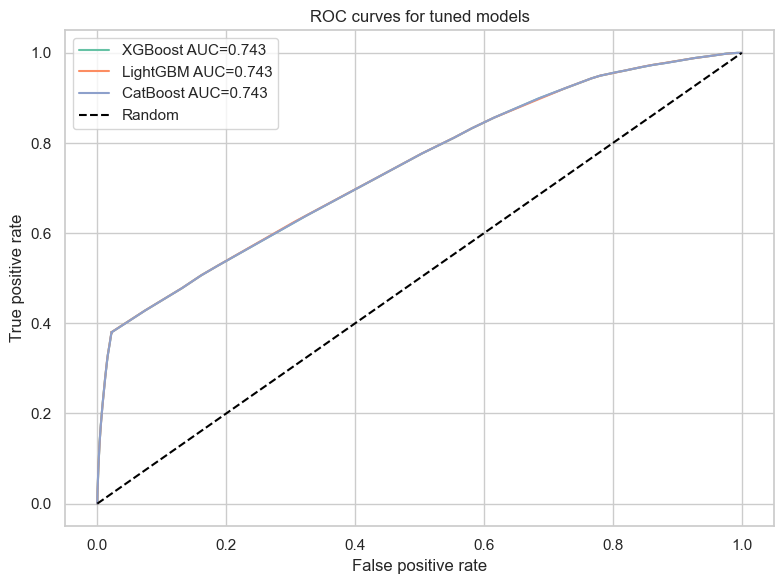

In [14]:
if not tuned_results.empty:
    display(tuned_results.sort_values(["roc_auc", "f1"], ascending=False))

    tuned_plot = tuned_results.set_index("model")[metric_columns]
    ax = tuned_plot.sort_values("roc_auc").plot(kind="barh", figsize=(12, 6))
    ax.set_title("Tuned model comparison")
    ax.set_xlabel("Score")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    for name, model in tuned_models.items():
        y_score = predict_scores(model, X_test)
        thresholds = np.linspace(0, 1, 101)
        tpr_values = []
        fpr_values = []
        y_true = np.asarray(y_test)
        for threshold in thresholds:
            y_pred_threshold = (y_score >= threshold).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred_threshold).ravel()
            tpr_values.append(tp / max(tp + fn, 1))
            fpr_values.append(fp / max(fp + tn, 1))
        plt.plot(fpr_values, tpr_values, label=f"{name} AUC={roc_auc_score(y_test, y_score):.3f}")

    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title("ROC curves for tuned models")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No tuned model results to plot. Use the baseline comparison above.")


## 15. Save the Best Final Model

The best tuned model is saved if tuning completes. If tuning fails or is interrupted, the notebook still saves the best baseline model instead. The model file and a small metadata file are saved under `ml_outputs/models`, so you can see exactly what was trained and which features it expects.


In [15]:
if not tuned_results.empty:
    final_table = tuned_results.copy()
    model_lookup = tuned_models
    source = "tuned"
else:
    final_table = valid_baselines.copy()
    model_lookup = fitted_models
    source = "baseline"

best_row = final_table.sort_values(["roc_auc", "f1"], ascending=False).iloc[0]
best_model_name = best_row["model"]
best_model = model_lookup[best_model_name]

model_path = MODEL_DIR / "best_covid_symptom_model.joblib"
metadata_path = MODEL_DIR / "best_covid_symptom_model_metadata.json"

dump(best_model, model_path)

metadata = {
    "best_model_name": best_model_name,
    "source": source,
    "feature_columns": MODEL_FEATURE_COLUMNS,
    "symptom_columns": SYMPTOM_COLUMNS,
    "context_columns": CONTEXT_COLUMNS,
    "target_column": TARGET_COLUMN,
    "n_rows_requested": N_ROWS,
    "n_rows_used": int(len(df)),
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "metrics": best_row.to_dict(),
}

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"Saved best model: {model_path.resolve()}")
print(f"Saved metadata: {metadata_path.resolve()}")
print("\nBest model summary:")
print(json.dumps(metadata, indent=2, default=str))


Saved best model: C:\Users\edyki\OneDrive\Documents\CodexFolder\ml_outputs\models\best_covid_symptom_model.joblib
Saved metadata: C:\Users\edyki\OneDrive\Documents\CodexFolder\ml_outputs\models\best_covid_symptom_model_metadata.json

Best model summary:
{
  "best_model_name": "LightGBM",
  "source": "tuned",
  "feature_columns": [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache",
    "symptom_count",
    "has_any_symptom",
    "has_multiple_symptoms",
    "age_60_and_above_yes",
    "gender_female",
    "gender_male",
    "test_indication_abroad",
    "test_indication_contact with confirmed",
    "test_indication_other",
    "test_month",
    "test_dayofweek"
  ],
  "symptom_columns": [
    "cough",
    "fever",
    "sore_throat",
    "shortness_of_breath",
    "head_ache"
  ],
  "context_columns": [
    "test_date",
    "age_60_and_above",
    "gender",
    "test_indication"
  ],
  "target_column": "corona_result",
  "n_rows_requested": 1000000,


## 16. Load and Use the Saved Model

This final cell shows how to load the saved model and make a prediction for one patient-like row. The same feature engineering function is used, then the columns are aligned to the training columns before prediction.


In [16]:
from joblib import load

loaded_model = load(MODEL_DIR / "best_covid_symptom_model.joblib")

example_raw_patient = pd.DataFrame(
    [
        {
            "test_date": "2021-10-11",
            "cough": 1,
            "fever": 1,
            "sore_throat": 0,
            "shortness_of_breath": 0,
            "head_ache": 1,
            "age_60_and_above": "No",
            "gender": "female",
            "test_indication": "Other",
        }
    ]
)

example_patient = make_features(example_raw_patient).reindex(columns=MODEL_FEATURE_COLUMNS, fill_value=0)
probability_positive = predict_scores(loaded_model, example_patient)[0]
predicted_class = int(probability_positive >= 0.5)

print(f"Predicted class: {predicted_class}")
print(f"Probability positive: {probability_positive:.4f}")


Predicted class: 1
Probability positive: 0.9876
